/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/dis


===== FOLD 0 =====

=== FOLD 0 ===
Subjects: train=140, val=46, test=46
FP/day ≤ 0.10: Th=0.8307, Sens=0.6600, Spec=0.9925, PPV=0.9429, NPV=0.9393, F1=0.7765, FP/day=0.1811
FP/day ≤ 0.25: Th=0.8076, Sens=0.6800, Spec=0.9925, PPV=0.9444, NPV=0.9427, F1=0.7907, FP/day=0.1811
FP/day ≤ 0.50: Th=0.8076, Sens=0.6800, Spec=0.9925, PPV=0.9444, NPV=0.9427, F1=0.7907, FP/day=0.1811
FP/day ≤ 1.00: Th=0.7244, Sens=0.7200, Spec=0.9887, PPV=0.9231, NPV=0.9493, F1=0.8090, FP/day=0.2717
Sensitivity ≥ 0.90: Th=0.1762, Sens=0.9000, Spec=0.8755, PPV=0.5769, NPV=0.9789, F1=0.7031, FP/day=2.9887
Sensitivity ≥ 0.95: Th=0.0798, Sens=0.9400, Spec=0.7774, PPV=0.4434, NPV=0.9856, F1=0.6026, FP/day=5.3434

===== FOLD 1 =====

=== FOLD 1 ===
Subjects: train=140, val=46, test=46
FP/day ≤ 0.10: Th=0.7359, Sens=0.7778, Spec=0.9847, PPV=0.8974, NPV=0.9627, F1=0.8333, FP/day=0.3664
FP/day ≤ 0.25: Th=0.6878, Sens=0.7778, Spec=0.9695, PPV=0.8140, NPV=0.9621, F1=0.7955, FP/day=0.7328
FP/day ≤ 0.50: Th=0.6878, Sens=0.777

,Operating Point,threshold,sensitivity,specificity,ppv,npv,f1,fp_day
0,FP/day ≤ 0.10,0.661 ± 0.188,0.767 ± 0.070,0.994 ± 0.005,0.959 ± 0.036,0.957 ± 0.011,0.851 ± 0.048,0.148 ± 0.124
1,FP/day ≤ 0.25,0.601 ± 0.188,0.793 ± 0.064,0.989 ± 0.010,0.934 ± 0.061,0.962 ± 0.010,0.856 ± 0.053,0.254 ± 0.242
2,FP/day ≤ 0.50,0.563 ± 0.186,0.813 ± 0.075,0.986 ± 0.010,0.913 ± 0.063,0.965 ± 0.013,0.857 ± 0.056,0.338 ± 0.241
3,FP/day ≤ 1.00,0.384 ± 0.196,0.866 ± 0.074,0.957 ± 0.034,0.806 ± 0.134,0.974 ± 0.013,0.825 ± 0.074,1.036 ± 0.822
4,Sensitivity ≥ 0.90,0.299 ± 0.121,0.889 ± 0.023,0.943 ± 0.042,0.760 ± 0.147,0.978 ± 0.005,0.813 ± 0.088,1.369 ± 0.998
5,Sensitivity ≥ 0.95,0.138 ± 0.106,0.947 ± 0.032,0.822 ± 0.145,0.574 ± 0.227,0.988 ± 0.008,0.685 ± 0.174,4.272 ± 3.492



===== POOLED OOF CALIBRATION =====
Brier score: 0.0407


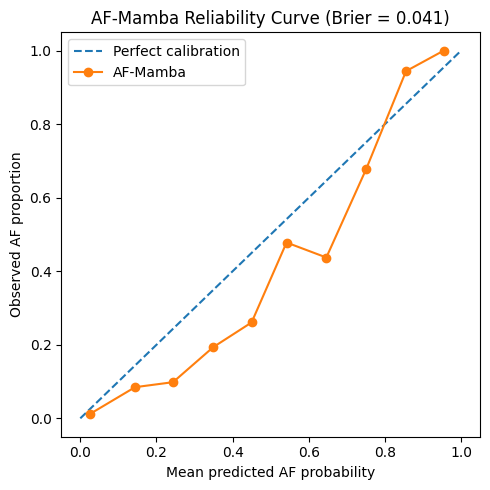

In [3]:
from pathlib import Path
import numpy as np,pandas as pd,torch,matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
from data_utils import seed_everything,build_datasets
from evaluation import _predict_torch,threshold_at_sensitivity,threshold_at_max_fp_day,clinical_metrics
from Models.AF_mamba import AFMamba

DATA=Path("Data/structured_dataset_1hz.pt"); FOLDS=Path("Data/subject_folds.pt"); CKPT=Path("Trained_Models/af_mamba")
BATCH_SIZE=16; INPUT_SIZE=3600; HORIZON=3600; WINDOW_HOURS=1.0; SEED=42
OPS={"FP/day ≤ 0.10":("fp",0.10),"FP/day ≤ 0.25":("fp",0.25),"FP/day ≤ 0.50":("fp",0.50),"FP/day ≤ 1.00":("fp",1.00),"Sensitivity ≥ 0.90":("sens",0.90),"Sensitivity ≥ 0.95":("sens",0.95)}

device=torch.device("cuda" if torch.cuda.is_available() else "cpu"); seed_everything(SEED)
data=torch.load(DATA,weights_only=False); folds=torch.load(FOLDS,weights_only=False)
af_sets,nsr_sets=folds["af_sets"],folds["nsr_sets"]

results={k:[] for k in OPS}; all_y=[]; all_scores=[]

for fold in range(5):
    print(f"\n===== FOLD {fold} =====")
    _,val_loader,test_loader,*_=build_datasets(data,af_sets,nsr_sets,fold,input_segment_size=INPUT_SIZE,prediction_horizon=HORIZON,batch_size=BATCH_SIZE)

    model=AFMamba().to(device)
    model.load_state_dict(torch.load(CKPT/f"fold_{fold}.pt",map_location=device,weights_only=True))

    val_y,val_scores=_predict_torch(model,val_loader,device)
    test_y,test_scores=_predict_torch(model,test_loader,device)
    all_y.append(test_y); all_scores.append(test_scores)

    for name,(kind,target) in OPS.items():
        th=threshold_at_max_fp_day(val_y,val_scores,target,WINDOW_HOURS) if kind=="fp" else threshold_at_sensitivity(val_y,val_scores,target)
        m=clinical_metrics(test_y,test_scores,th,WINDOW_HOURS); results[name].append(m)
        print(f"{name}: Th={m['threshold']:.4f}, Sens={m['sensitivity']:.4f}, Spec={m['specificity']:.4f}, PPV={m['ppv']:.4f}, NPV={m['npv']:.4f}, F1={m['f1']:.4f}, FP/day={m['fp_day']:.4f}")

keys=["threshold","sensitivity","specificity","ppv","npv","f1","fp_day"]
summary=[]
for name,fold_results in results.items():
    row={"Operating Point":name}
    for k in keys:
        v=np.array([m[k] for m in fold_results],dtype=float)
        row[k]=f"{v.mean():.3f} ± {v.std():.3f}"
    summary.append(row)

summary_df=pd.DataFrame(summary)
print("\n===== OPERATING POINT SUMMARY =====")
display(summary_df)

all_y=np.concatenate(all_y); all_scores=np.concatenate(all_scores)
brier=brier_score_loss(all_y,all_scores)
prob_true,prob_pred=calibration_curve(all_y,all_scores,n_bins=10,strategy="uniform")

print("\n===== POOLED OOF CALIBRATION =====")
print(f"Brier score: {brier:.4f}")

plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1],"--",label="Perfect calibration")
plt.plot(prob_pred,prob_true,"o-",label="AF-Mamba")
plt.xlabel("Mean predicted AF probability"); plt.ylabel("Observed AF proportion")
plt.title(f"AF-Mamba Reliability Curve (Brier = {brier:.3f})")
plt.legend(); plt.tight_layout(); plt.show()